In [9]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
import sys, pathlib
# adjust this to your repo root if different
repo_root = pathlib.Path.cwd()

# If running from the playground directory, move up one level to the repo root
if repo_root.name == 'playground':
    repo_root = repo_root.parent

sys.path.insert(0, str(repo_root))
print('Inserted repo root into sys.path:', repo_root)

Inserted repo root into sys.path: C:\Users\f.spreemann\qecsim-work


In [11]:
from src.codes.surface_code_rotated.builder import SurfaceBuilder

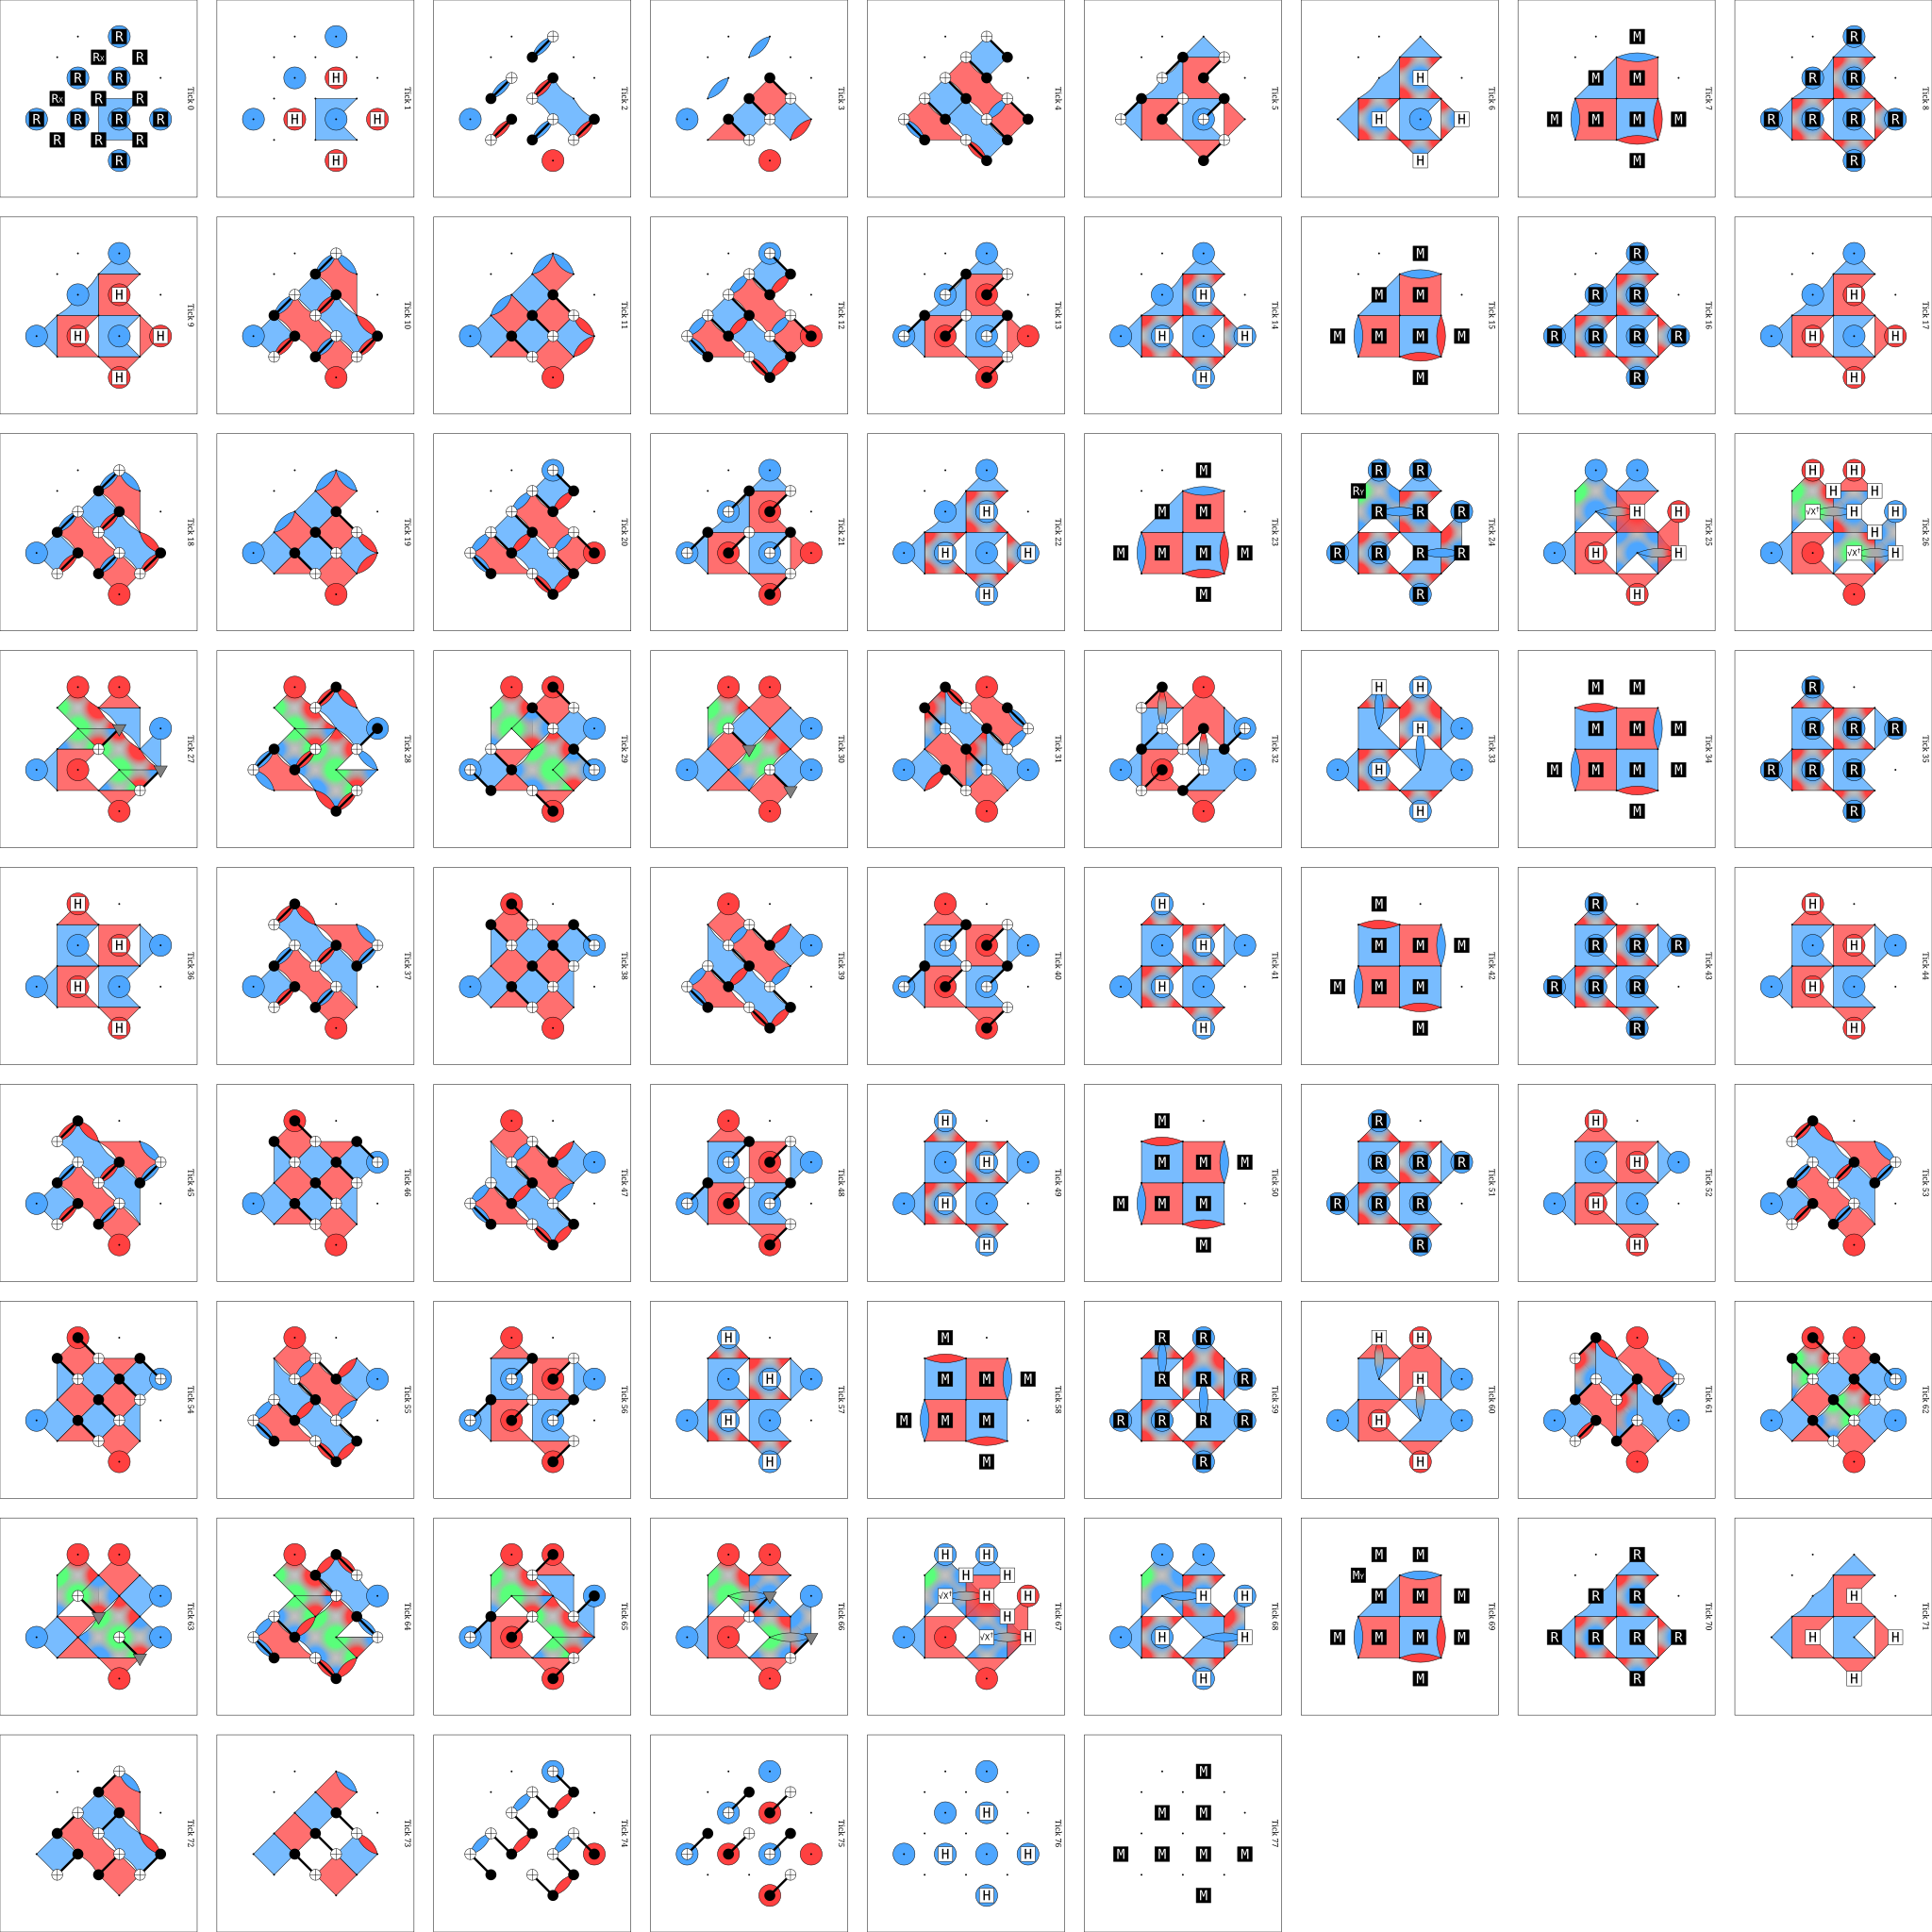

In [12]:
test_builder = SurfaceBuilder(distance=3, state_init="+i", log_obs="Y")
test_circuit = test_builder.build_circuit()

test_circuit.diagram("detslice-with-ops-svg")


In [13]:
from src.codes.lattice_surgery.builder import SurgeryBuilder

In [14]:
test_surgery_builder = SurgeryBuilder(distance = 3, control_state_init= "X+", target_state_init= "Z0", control_measure_basis= "Y", target_measure_basis= "Y")

test_surgery_circuit = test_surgery_builder.build_circuit()
test_measurement_rec = test_surgery_builder.get_logical_meas_rec(observable_index=0)

print(test_surgery_circuit)
print(test_measurement_rec)

QUBIT_COORDS(0, 2) 0
QUBIT_COORDS(0, 6) 1
QUBIT_COORDS(0, 10) 2
QUBIT_COORDS(1, 1) 3
QUBIT_COORDS(1, 3) 4
QUBIT_COORDS(1, 5) 5
QUBIT_COORDS(1, 7) 6
QUBIT_COORDS(1, 9) 7
QUBIT_COORDS(1, 11) 8
QUBIT_COORDS(2, 2) 9
QUBIT_COORDS(2, 4) 10
QUBIT_COORDS(2, 6) 11
QUBIT_COORDS(2, 8) 12
QUBIT_COORDS(2, 10) 13
QUBIT_COORDS(3, 1) 14
QUBIT_COORDS(3, 3) 15
QUBIT_COORDS(3, 5) 16
QUBIT_COORDS(3, 7) 17
QUBIT_COORDS(3, 9) 18
QUBIT_COORDS(3, 11) 19
QUBIT_COORDS(4, 0) 20
QUBIT_COORDS(4, 2) 21
QUBIT_COORDS(4, 4) 22
QUBIT_COORDS(4, 6) 23
QUBIT_COORDS(4, 8) 24
QUBIT_COORDS(4, 10) 25
QUBIT_COORDS(4, 12) 26
QUBIT_COORDS(5, 1) 27
QUBIT_COORDS(5, 3) 28
QUBIT_COORDS(5, 5) 29
QUBIT_COORDS(5, 7) 30
QUBIT_COORDS(5, 9) 31
QUBIT_COORDS(5, 11) 32
QUBIT_COORDS(6, 2) 33
QUBIT_COORDS(6, 4) 34
QUBIT_COORDS(6, 6) 35
QUBIT_COORDS(6, 8) 36
QUBIT_COORDS(6, 10) 37
QUBIT_COORDS(7, 1) 38
QUBIT_COORDS(7, 3) 39
QUBIT_COORDS(7, 5) 40
QUBIT_COORDS(8, 0) 41
QUBIT_COORDS(8, 2) 42
QUBIT_COORDS(8, 4) 43
QUBIT_COORDS(9, 1) 44
QUBIT_COORDS

In [15]:
import pymatching

from src.core.data_models import NoiseParameters

noise = 0

noise_class = NoiseParameters(before_round_depol = noise,
    before_m_flip_prob = noise,
    after_r_flip = noise,
    after_c_depol_prob = noise,
    after_c_pauli_channel_prob = noise)

# define Circuit
test_surgery_builder = SurgeryBuilder(distance = 3, control_state_init= "X+", target_state_init= "I", control_measure_basis= "X", target_measure_basis= "X", noise = noise_class)
test_surgery_circuit = test_surgery_builder.build_circuit()

# Sample the circuit.
sampler = test_surgery_circuit.compile_detector_sampler()
detection_events, observable_flips = sampler.sample(1_000, separate_observables=True)

# Configure a decoder using the circuit.
detector_error_model = test_surgery_circuit.detector_error_model(decompose_errors=True)
matcher = pymatching.Matching.from_detector_error_model(detector_error_model)

# Run the decoder.
predictions = matcher.decode_batch(detection_events)

predictions, observable_flips

(array([[0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],

In [16]:
import numpy as np

sampler = test_surgery_circuit.compile_sampler()
results_samples = sampler.sample(shots=1000)

final_res = 0
for i in test_measurement_rec:
    final_res ^= results_samples[:,i].astype(np.int8)
print(final_res)

[1 0 1 0 1 0 1 0 1 1 0 0 0 1 0 0 1 0 1 0 0 1 1 0 1 1 0 1 0 1 0 0 1 1 0 0 0
 0 1 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 1 0 1 0 1 0 0 0 1 1 0 1 1 0 1 0 1 0 1 0
 0 1 1 1 0 1 0 1 1 0 1 0 0 0 1 1 0 0 1 1 0 0 0 0 1 0 1 1 1 0 1 0 0 0 0 1 0
 1 0 1 0 0 1 0 1 0 1 1 1 1 1 1 0 1 1 0 0 1 0 0 1 1 1 0 1 0 0 0 0 0 1 0 1 0
 0 0 0 1 0 1 1 1 1 1 0 1 1 1 1 1 1 0 0 1 0 1 0 1 1 1 0 1 0 1 1 1 1 1 1 1 0
 0 0 0 1 0 1 0 0 0 0 1 1 0 1 0 1 0 1 0 0 1 1 0 1 1 0 0 1 0 0 1 0 1 1 0 0 1
 1 1 0 1 0 0 1 0 1 0 0 0 0 0 1 0 1 1 0 0 0 0 0 1 1 1 0 1 1 0 0 0 0 0 1 1 0
 1 0 1 0 0 0 0 1 0 1 0 0 0 1 1 0 1 1 0 1 0 1 0 0 1 1 1 0 0 1 1 0 1 1 0 1 0
 0 0 1 1 1 1 1 0 1 0 0 0 0 0 1 1 1 0 1 0 1 1 0 0 1 0 0 0 0 1 1 0 0 0 0 0 1
 1 1 0 0 0 0 1 0 0 1 1 0 1 0 1 0 1 1 1 1 0 1 1 0 1 0 0 0 0 0 0 1 1 1 1 1 1
 0 1 1 1 0 1 1 1 0 1 0 0 1 1 0 0 1 1 0 1 1 0 0 0 0 1 1 0 0 1 0 1 0 1 1 1 0
 1 0 0 1 1 0 0 1 1 0 1 0 1 1 1 1 1 1 0 1 0 0 1 1 0 0 0 0 1 0 0 0 1 0 1 0 1
 0 0 1 0 1 0 1 1 0 0 0 0 0 1 0 0 0 0 1 0 1 0 1 0 0 0 1 0 0 1 0 1 0 1 0 0 1
 1 0 1 0 0 1 0 0 1 0 1 1 